In this article, we will dive into the fundamentals of Retrieval-Augmented Generation (RAG) and vector databases. Finally, we will build a practical Customer Support Q&A chatbot that leverages RAG to incorporate external documents and provide more accurate and context-aware answers.

## Retrieval-Augmented Generation

Retrieval-Augmented Generation (RAG) is a technique developed to improve the accuracy and reliability of Large Language Models (LLMs) by reducing hallucinations and enhancing contextual understanding. Introduced by Meta’s FAIR team, RAG combines information retrieval with text generation by fetching relevant information from external knowledge sources before the model generates a response.

Instead of relying solely on the model’s internal training data, RAG enriches prompts with relevant external content such as PDFs, private documents, code repositories, websites, or SQL databases. This enables chatbots and AI assistants to provide more precise, up-to-date, and context-aware answers.

One of the major advantages of RAG is its ability to reference or cite the sources used to generate responses, which improves transparency and user trust. Additionally, RAG makes it easier to integrate domain-specific or frequently updated information without the need for expensive and complex fine-tuning of the LLM.




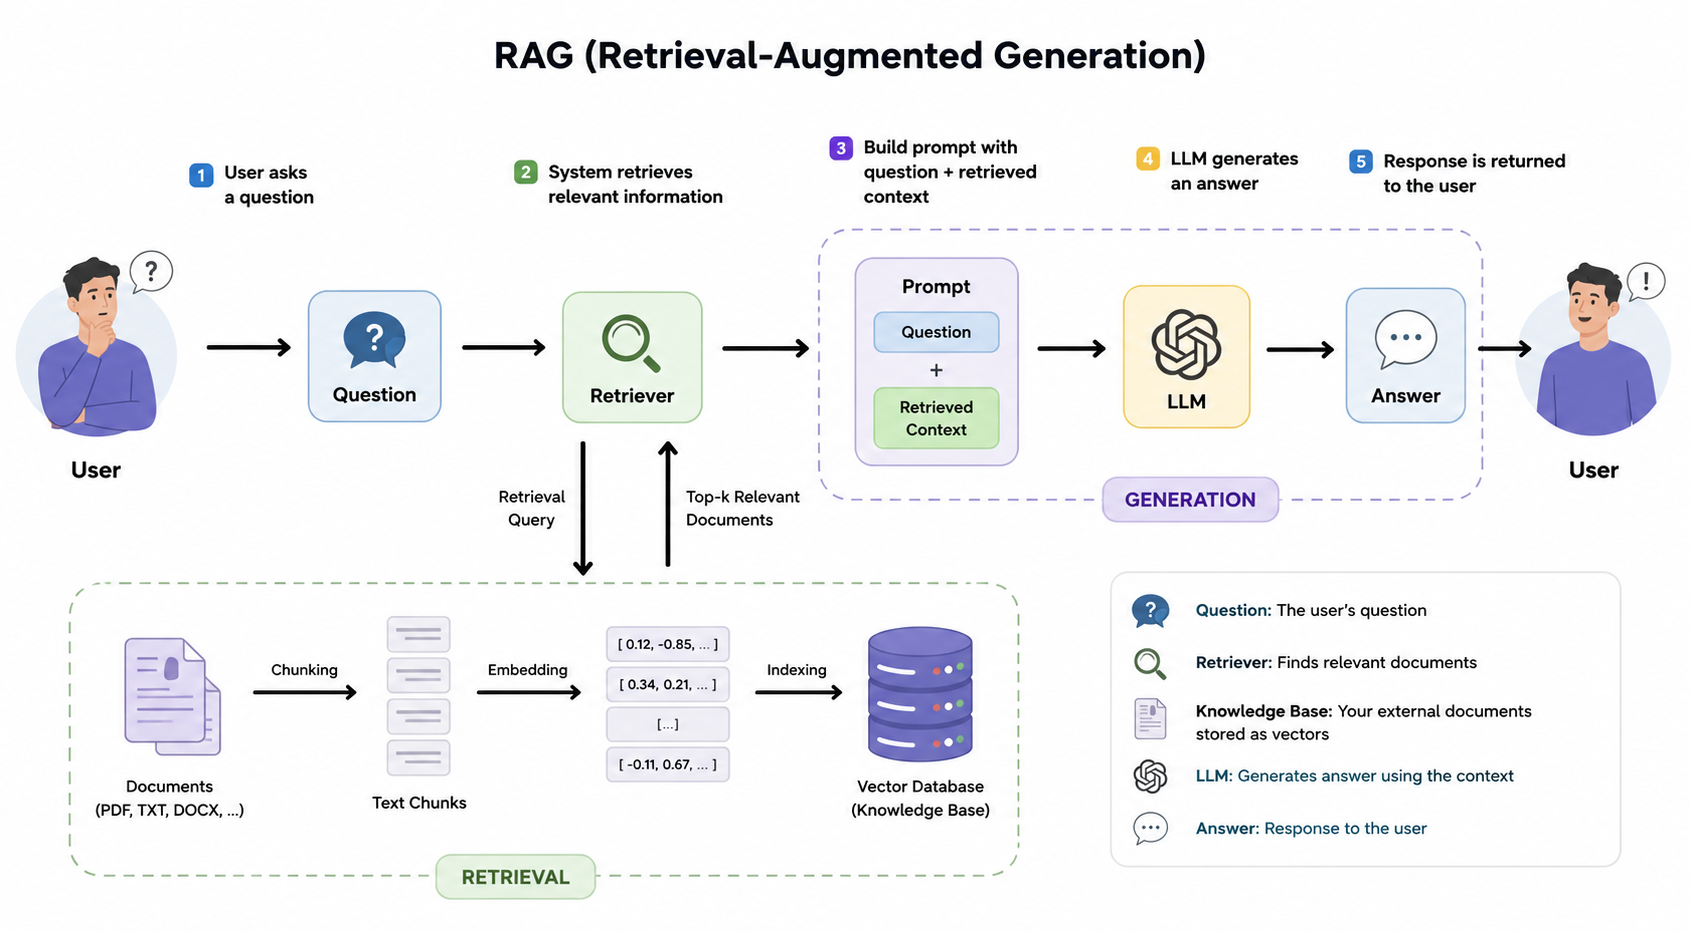

The  diagram illustrates the overall workflow of a Retrieval-Augmented Generation (RAG) system. It shows how a user’s question is first processed by a retriever, which searches a vector database or knowledge base to find the most relevant information. The retrieved context is then combined with the original question and sent to the Large Language Model (LLM), enabling it to generate more accurate, contextual, and reliable responses.

## 1.  The Impact of Larger Context Windows

Modern LLMs with larger context windows can process much more text at once, which raises an important question: should we provide the entire document set or only the most relevant information?

Although providing complete documents gives the model access to broader context, it also introduces several drawbacks:

+ Higher latency due to the processing of large amounts of text.
+ Reduced accuracy when relevant information is buried inside long documents.
+ Higher computational costs and inefficient resource usage, especially with large datasets.

For this reason, retrieving only the most relevant information is often more efficient and effective for RAG systems.

Libraries such as LangChain and LlamaIndex provide user-friendly tools for building retrieval systems on custom data sources. In this article, we focus on LangChain’s indexing capabilities to create a simple RAG pipeline for uploading, indexing, and querying documents.

In the next article, we will explore LlamaIndex for more advanced retrieval-augmented generation workflows.

## 2. LangChain’s Indexes and Retrievers

In LangChain, an **index** organizes and stores data for fast and efficient search, while a **retriever** uses this index to find the most relevant documents for a given query.

Most LangChain indexes rely on **vector databases** and **embeddings** to handle unstructured data efficiently. Retrievers then extract relevant information and pass it to the LLM to generate accurate and context-aware responses.





Let’s see how they work with a practical application:






 * Install the required Python packages, then use the TextLoader class to load
text files and create LangChain Document objects



In [ ]:
!pip install langchain deeplake openai tiktoken

In [16]:
from langchain.document_loaders import TextLoader

# Text adapted from general information about Large Language Models (LLMs)
# inspired by OpenAI, Google DeepMind, and Meta AI documentation

text = """
Large Language Models (LLMs) are advanced AI systems trained on massive
amounts of text data to understand and generate human language.
Models such as GPT, Gemini, and LLaMA can perform a wide range of tasks,
including text summarization, translation, question answering, code
generation, and conversational assistance.

LLMs rely on deep learning and transformer architectures to capture
context and relationships between words. Their ability to generate
coherent and context-aware responses has transformed many industries,
including education, healthcare, finance, and customer support.

Despite their impressive capabilities, LLMs may sometimes generate
incorrect or outdated information. Techniques such as Retrieval-Augmented
Generation (RAG) help improve their accuracy by connecting them to
external and up-to-date knowledge sources.
"""

# Write text to a local file
with open("llm_text.txt", "w") as file:
    file.write(text)

# Load the text file using TextLoader
loader = TextLoader("llm_text.txt")
docs_from_file = loader.load()

# Print the number of loaded documents
print(len(docs_from_file))

1


* Use **CharacterTextSplitter** to divide documents into smaller text segments called **chunks**. The chunk_overlap parameter defines how many characters are shared between consecutive chunks, helping preserve context and maintain coherence by preventing important information from being split at chunk boundaries.

In [51]:
from langchain.text_splitter import CharacterTextSplitter
# create a text splitter
text_splitter = CharacterTextSplitter(chunk_size=200,
chunk_overlap=20)
# split documents into chunks
docs = text_splitter.split_documents(docs_from_file)
print(len(docs))



3


**Note:** Some generated chunks may slightly exceed the specified chunk_size. This occurs when the text splitter preserves complete sentences or separators to maintain better context and readability.

You can resolve this issue by specifying better separators or reducing the chunk size strategy.
The most common solution is to use **RecursiveCharacterTextSplitter**, which splits text more intelligently.

In [18]:
from langchain.text_splitter import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=200,
    chunk_overlap=20,
    separators=["\n\n", "\n", " ", ""]
)

chunks = text_splitter.split_documents(docs_from_file)

print(len(chunks))

6


* Create a vector embedding for each text snippet.


Generate a vector embedding for each text chunk. These embeddings enable semantic search by identifying documents or text segments that are most relevant to a query based on their meaning and contextual similarity. In this example, we use OpenAI’s embedding model to create the embeddings.



Before running the code, make sure you have set up an OpenAI API account and generated an API key to access the embedding model. You can create your API key from OpenAI Platform
.

In [20]:
from langchain_openai import OpenAIEmbeddings
# Before executing the following code, make sure to have
# your OpenAI key saved in the "OPENAI_API_KEY" environment
embeddings = OpenAIEmbeddings(model="text-embedding-ada-002")

A **vector store** is a database designed to store and retrieve vector embeddings efficiently for semantic search and similarity matching. In this example, we use **Deep Lake**, a cloud-based vector store developed by Activeloop, although other solutions such as ChromaDB can also be used.

Next, we create a Deep Lake dataset and generate embeddings using the **embedding_function**.

To follow along, create a free Activeloop account at Activeloop
.

In [21]:
#Create a vector store: Deep Lake

my_activeloop_dataset_name="langchain_article_indexers_retrievers"#
my_activeloop_org_id="justindjakas4" #"<YOUR-ACTIVELOOP-ORG-ID>"

dataset_path=f"hub://{my_activeloop_org_id}/{my_activeloop_dataset_name}"


db = DeeplakeVectorStore(dataset_path=dataset_path,embedding_function=embeddings)

#Add documents to the Deep Lake dataset
db.add_documents(docs)

['41358085-c680-4176-a6a5-ac630f0a5ffc',
 '63ebb920-a6ed-4dd3-bd45-8f131b5ec3a5',
 'bd546b1e-3a0f-4fe7-9e41-342f4f2de25d']

* The next step is to create a LangChain retriever by calling the .as_retriever() method on the vector store instance.

In [22]:
# create retriever from db
retriever = db.as_retriever()

* Once we have the retriever, we can use the RetrievalQA class to
define a question answering chain using external data source and
start with question-answering.

In [24]:
from langchain.chains import RetrievalQA
from langchain_openai import OpenAI
# create a retrieval chain
qa_chain = RetrievalQA.from_chain_type(
    llm=OpenAI(model="gpt-3.5-turbo"),
    chain_type= "stuff",
    retriever=retriever)

We can query our document about a specific topic found in the
documents.

> Add blockquote



In [30]:


# Create the LLM
llm = ChatOpenAI(
    model_name="gpt-3.5-turbo",
    temperature=0
)

# Create the QA chain
qa_chain = RetrievalQA.from_chain_type(
    llm=llm,
    chain_type="stuff",
    retriever=retriever
)

# Query
query = "What are Large Language Models (LLMs) and how does RAG improve their accuracy?"

# Generate response
response = qa_chain.invoke(query)

print(response["result"])

Large Language Models (LLMs) are advanced AI systems trained on vast amounts of text data to understand and generate human language. They can perform various tasks like text summarization, translation, question answering, code generation, and conversational assistance. LLMs use deep learning and transformer architectures to capture context and relationships between words, enabling them to generate coherent and context-aware responses.

Retrieval-Augmented Generation (RAG) is a technique used to enhance the accuracy of LLMs by connecting them to external and up-to-date knowledge sources. By incorporating additional information from these external sources, LLMs can generate more accurate and relevant responses, reducing the chances of producing incorrect or outdated information. This helps improve the overall performance and reliability of Large Language Models.


## How It Works Internally

Using chain_type="stuff" means that all retrieved documents are directly inserted into the prompt before being sent to the LLM. This approach is simple and effective for small datasets, but it can become limited by the context window size of the model.

The system also performs a semantic similarity search using embeddings to retrieve the most relevant document chunks related to the user query. This allows the LLM to receive focused and context-aware information instead of processing entire documents.

This example highlights how retrievers, embeddings, and vector databases such as Deep Lake improve the ability of LLMs to work efficiently with external knowledge sources.

```
# This is formatted as code
```




🎉 Congratulations — you have just built your first Retrieval-Augmented Generation (RAG) system!

## A Potential Problem

Even when using RecursiveCharacterTextSplitter, a potential challenge remains when working with large datasets. Although this splitter improves chunk creation by using better separators and reducing oversized chunks, some retrieved chunks may still contain information that is not fully relevant to the user’s query.

Including unrelated content in the LLM prompt can be problematic because:

* It may distract the model from the most important information.
* It consumes valuable context space that could be used for more relevant chunks.



## Possible Solution

A possible solution is to use a DocumentCompressor to filter and keep only the most relevant information from retrieved documents. Instead of sending complete chunks directly to the LLM, the system compresses the content based on the user query.

In LangChain, the ContextualCompressionRetriever combines a retriever with a compressor to return only the most relevant document sections. A common approach is to use LLMChainExtractor, which leverages an LLM to extract the sentences or passages that best match the query.

This helps reduce irrelevant context, improve response quality, and optimize prompt usage.


The following example demonstrates the application of the
ContextualCompressionRetriever with the LLMChainExtractor:

In [34]:
from langchain.retrievers import ContextualCompressionRetriever
from langchain.retrievers.document_compressors import LLMChainExtractor
#Create GPT3 Wrapper
llm = ChatOpenAI(
    model_name="gpt-3.5-turbo",
    temperature=0
)

#Create a compressor for the retriever
compressor = LLMChainExtractor.from_llm(llm)
compression_retriever = ContextualCompressionRetriever(base_compressor=compressor,
                                                       base_retriever=retriever)


Once the compression_retriever is created, we can use it to retrieve the most relevant compressed documents for a given query.

In [36]:
# Retrieving compressed documents
retrieved_docs = compression_retriever.invoke(
    "What are Large Language Models (LLMs) and how does RAG improve their accuracy?"
)

print(retrieved_docs[0].page_content)

Techniques such as Retrieval-Augmented Generation (RAG) help improve their accuracy by connecting them to external and up-to-date knowledge sources.


Compressors help optimize RAG systems by sending only the most relevant information to the LLM. This reduces unnecessary context, improves response quality, and allows the model to focus on essential content. It also enables the retriever to return more documents while relying on the compressor to keep only the most useful information.

In this example, we created a retriever from a simple .txt file, but in real-world applications, data can come from many different sources. Fortunately, LangChain provides loaders for PDFs, websites, Google Drive, databases, and many other formats that we will explore in future articles.

🎉 Thank you for making it this far! You have now discovered the core architecture and workflow behind a basic RAG-powered LLM system.

If you have followed this article up to this point, you now have a solid foundation in building a basic RAG architecture. Now, let’s move from theory to practice by exploring a real-world business use case: building a Customer Support Q&A Chatbot powered by RAG.

## A Customer Support Q&A Chatbot
In this project, we will build a Customer Support Q&A chatbot powered by GPT and Retrieval-Augmented Generation (RAG) to answer questions directly from business documents.

Traditionally, chatbots relied on predefined intents and scripted responses tailored to specific business scenarios. For example, in an e-commerce platform, customers might ask questions such as:

* “Where is my order?”
* “How can I return a product?”
* “Can I get a refund?”

The chatbot would then match the query to a predefined intent and return a fixed response.

While this approach works well for repetitive and structured queries, it becomes limited when users ask unexpected or more complex questions.

With the rise of Large Language Models (LLMs), modern chatbots can now understand context, retrieve information from external knowledge sources, and generate more natural and accurate responses. In this section, we will build a simple RAG-based customer support assistant capable of answering questions from custom documents.

In [1]:
from dotenv import load_dotenv
import os
from openai import OpenAI

# Replace the path with the full path to your .env file
load_dotenv('/content/drive/MyDrive/llms_for_production/.env')

# Access the keys as environment variables
openai_key = os.getenv("OPENAI_API_KEY")
deeplake_token = os.getenv("DEEPLAKE_TOKEN")

print("Keys loaded:", bool(openai_key), bool(deeplake_token))

client=OpenAI(api_key=os.environ['OPENAI_API_KEY'])

Keys loaded: True True


1. Install the necessary Python packages and use the TextLoader class to load text files and create a LangChain Document object

In [ ]:
#Install langchain
!pip uninstall -q -y langchain langchain-core langchain-community langchain-text-splitters langchain-openai langchain-deeplake deeplake
!pip install -q -U "langchain<1.0" "langchain-openai" "langchain-community" "langchain-text-splitters" "langchain-deeplake" "deeplake" "tiktoken"

## Workflow

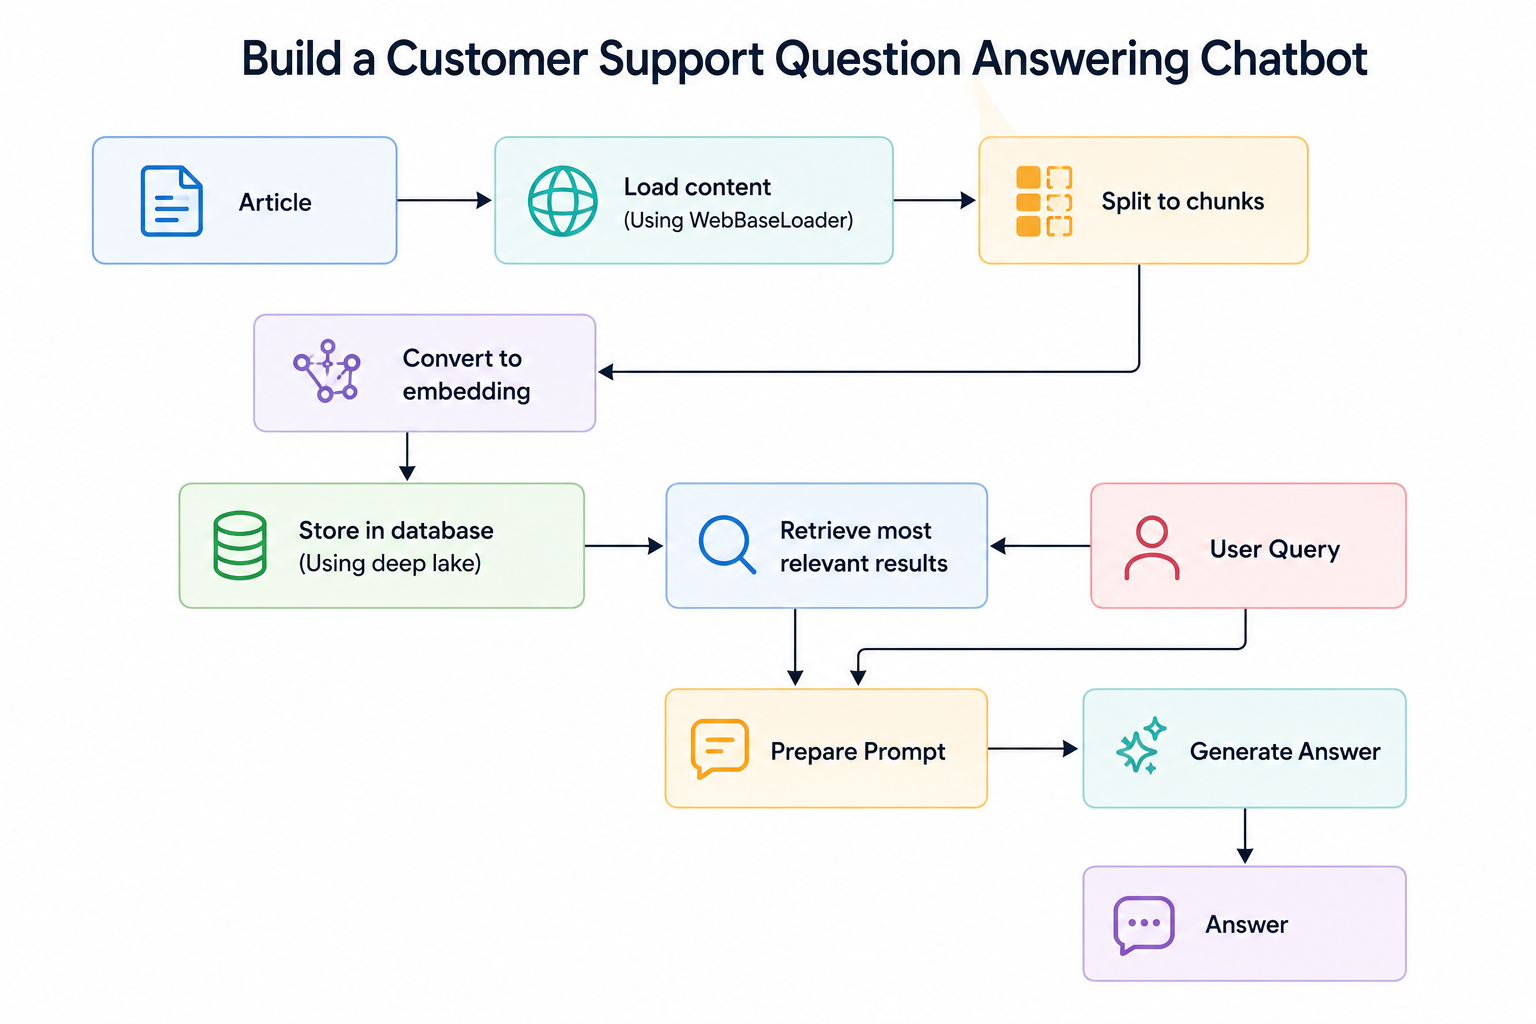

The first step is to extract content from online articles, split it into smaller chunks, generate embeddings, and store them in Deep Lake. When a user submits a query, the system retrieves the most relevant chunks and includes them in the prompt sent to the LLM to generate the final response.

Before starting, configure the OPENAI_API_KEY and ACTIVELOOP_TOKEN environment variables with your API credentials.

To load web content, we will use the WebBaseLoader class from LangChain.

In [37]:
from langchain_openai import OpenAIEmbeddings
from langchain_deeplake.vectorstores import DeeplakeVectorStore
from langchain_text_splitters import CharacterTextSplitter, RecursiveCharacterTextSplitter
from langchain_openai import  OpenAI
from langchain_community.document_loaders import UnstructuredMarkdownLoader,SeleniumURLLoader,WebBaseLoader
from langchain import PromptTemplate
from langchain.retrievers import ContextualCompressionRetriever
from langchain.retrievers.document_compressors import LLMChainExtractor
from langchain.retrievers import ContextualCompressionRetriever
from langchain.retrievers.document_compressors import LLMChainExtractor
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage



These libraries provide the core functionalities required to build a context-aware question-answering system, including generating embeddings, managing vector storage, splitting text into chunks, and interacting with the OpenAI API. Together, they enable the integration of information retrieval with LLM-based response generation.

In this example, we use technical support articles as the chatbot knowledge base. However, the same architecture can be applied to many other domains, such as healthcare, finance, e-commerce, legal documents, or internal company documentation.

In [5]:
# we'll use information from the following articles
urls = [
'https://beebom.com/what-is-nft-explained/',
'https://beebom.com/how-delete-spotify-account/',
'https://beebom.com/how-download-gif-twitter/',
'https://beebom.com/how-use-chatgpt-linux-terminal/',
'https://beebom.com/how-delete-spotify-account/',
'https://beebom.com/how-save-instagram-story-with-music/',
'https://beebom.com/how-install-pip-windows/',
'https://beebom.com/how-check-disk-usage-linux/']



1. Use Selenium scraper or WebBaseLoader to load the documents

Load the content from the provided URLs and split it into smaller chunks using CharacterTextSplitter with a chunk_size of 1000 and no overlap between chunks.

In [38]:
# Initialize the WebBaseLoader with the list of URLs
loader = WebBaseLoader(urls)

# Load the content from the web pages
docs_not_splitted = loader.load()

In [39]:
print(f'Number of documents={len(docs_not_splitted)}')

Number of documents=8


:2. Split the documents into chunks and compute
their embeddings

In [8]:
#Split the documents into smaller chunks
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=100
)
docs=text_splitter.split_documents(docs_not_splitted)

In [9]:
print(len(docs))

148


Next, generate embeddings using OpenAIEmbeddings and store them in a cloud-based Deep Lake vector store. In production environments, this approach allows applications to search across large collections of documents using a centralized and scalable dataset.

Update the code below with your Activeloop organization ID (by default, it is your username).

3. Create a vector embedding for each text snippet

In [10]:
# Initialize the OpenAI embedding model
# This model converts text chunks into numerical vector embeddings
embeddings = OpenAIEmbeddings(model="text-embedding-ada-002")

In [45]:
#Create a vector store: Deep Lake

my_activeloop_dataset_name="Customer_Support"
my_activeloop_org_id="justindjakas4"

dataset_path=f"hub://{my_activeloop_org_id}/{my_activeloop_dataset_name}"


db = DeeplakeVectorStore(dataset_path=dataset_path,embedding_function=embeddings)

#Add documents to the Deep Lake dataset
db.add_documents(docs)


['46ed8081-c306-414a-988b-c3bbcda579e1',
 'e97dd090-9d44-4b89-bf14-fee96670fe54',
 '7b173e0a-e0b1-4fb2-bfee-e23a4f344d8d']

To retrieve the most similar chunks to a given query, we can use
the similarity_search method of the Deep Lake vector store:

In [46]:
# let's see the top relevant documents to a specific query
query = "how to check disk usage in linux?"
docs = db.similarity_search(query)
print(docs[0].page_content)

There may be times when you need to download some important files or transfer some photos to your Linux system, but face a problem of insufficient disk space. You head over to your file manager to delete the large files which you no longer require, but you have no clue which of them are occupying most of your disk space. In this article, we will show some easy methods to check disk usage in Linux from both the terminal and the GUI application.
Check Disk Space Using the df Command
In Linux, there are many commands to check disk usage, the most common being the df command. The df stands for “Disk Filesystem” in the command, which is a handy way to check the current disk usage and the available disk space in Linux. The syntax for the df command in Linux is as follows:
df <options> <file_system>
The options to use with the df command are:


***4***. Craft a prompt for GPT-3 using the suggested strategies

For this chatbot, we will create a prompt template that combines role prompting, retrieved knowledge base context, and the user’s question to generate accurate and context-aware responses.

In [47]:
# let's write a prompt for a customer support chatbot that
# answer questions using information extracted from our db
template = """You are a helpful and professional customer support assistant.

Your goal is to answer customer questions using ONLY the provided context.

Guidelines:
- Be polite, clear, and concise.
- If the answer is not in the context, say: "I’m sorry, I don’t have enough information to answer that."
- Do NOT make up information.
- Use simple language.

Context:
{chunks_formatted}

Customer question:
{query}

Answer:"""

prompt = PromptTemplate(
    input_variables=["chunks_formatted", "query"],
    template=template,
)

The template defines the chatbot as an advanced customer support assistant and relies on two main inputs: chunks_formatted, containing relevant document segments, and query, representing the user’s question. The goal is to generate accurate, context-based responses while avoiding fabricated information.

5. Utilize the GPT-3 model with a temperature of 0 for text generation

In [53]:

# Initialize the chatbot model
llm = ChatOpenAI(
    model="gpt-3.5-turbo",
    temperature=0
)

print("Hi! I'm your AI technical support assistant.")
print("Type 'exit' to stop the chatbot.\n")

# Chat loop
while True:

    # User input
    query = input("You: ")

    # Exit condition
    if query.lower() == "exit":
        print("Chatbot: Goodbye!")
        break

    # Retrieve relevant chunks from the vector database
    docs = db.similarity_search(query)

    # Extract text content from retrieved documents
    retrieved_chunks = [doc.page_content for doc in docs]

    # Format retrieved context
    chunks_formatted = "\n\n".join(retrieved_chunks)

    # Build the final prompt
    prompt_formatted = prompt.format(
        chunks_formatted=chunks_formatted,
        query=query
    )

    # Generate chatbot response
    answer = llm.invoke([
        HumanMessage(content=prompt_formatted)
    ])

    # Display response
    print("\nChatbot:", answer.content)
    print("-" * 80)

Hi! I'm your AI technical support assistant.
Type 'exit' to stop the chatbot.

You: How to install pip on Windows?

Chatbot: To install Pip on Windows, you can follow these steps:
1. Right-click on this link and then choose “Save link as…”.
2. Save it as “get-pip.py” file in the “Downloads” folder.
3. Right-click on the “get-pip.py” file and choose “Copy as path”.
4. Open the Terminal, enter python, add a space, paste the path, and hit Enter.
5. You can also run this command: python -m ensurepip --upgrade.
--------------------------------------------------------------------------------
You: exit
Chatbot: Goodbye!


🎉 Congratulations! We have successfully built our first RAG-powered Customer Support Q&A chatbot.


Throughout this project, we explored the complete workflow behind a retrieval-augmented AI application: loading external documents, splitting them into chunks, generating embeddings, storing them in a vector database, retrieving relevant information through semantic search, and finally using an LLM to generate contextual answers.


We also discovered how tools such as LangChain, OpenAI embeddings, and Deep Lake work together to build intelligent systems capable of interacting with external knowledge sources instead of relying solely on the model's internal memory.


However, building a reliable chatbot is not only about generating answers. One of the main challenges of LLM-based systems remains hallucinations - cases where the model generates incorrect or unsupported information. In the next article, we will explore techniques to improve retrieval quality and build more reliable RAG architectures.

Thank you for reading this article! 🚀
Be sure to follow me on Medium for upcoming articles about data ingestion pipelines and more advanced RAG architectures using LlamaIndex.

The complete project code is available on GitHub:
https://github.com/Just1919/Customer-Support-Q-A-Chatbot

Feel free to connect with me on LinkedIn for more content on AI, Data Science, and LLM engineering:
https://www.linkedin.com/in/yawo-justin-djakas